# 📊 UP Budget 2026-27 — OCR Extraction & Analysis

**Source:** `khand2part2_2026_2027.pdf` — Pages 8–10 (Expenditure head-wise, ₹ in Lakhs)  

### Pipeline
1. **OCR Extraction** — `pdfplumber` + CID-safe relaxed regex parser  
2. **Data Cleaning** — garbage row removal, type correction, manual fix for Item 24  
3. **Analysis** — 8 charts: composition, trends, top heads, utilisation, gainers/losers

---
## 📝  — Key Insights

| # | Finding |
|---|---|
| 1 | **Strong overall growth:** Budget grew from ₹62,061 Cr (Actuals 24-25) → ₹94,003 Cr (Budget 26-27) — a **~51% jump** over 2 years. |
| 2 | **Revenue dominates** (~70%), reflecting a service-heavy, transfer-oriented expenditure profile. |
| 3 | **Top 3 heads** — Major Construction Works (#24), Pensions/Social Security (#33), Interest/Dividends (#32) — account for > 35% of Budget 26-27. |
| 4 | **Biggest % gainer:** Office Expenditure (#8) — up **136.7%** in Budget 26-27 vs Budget 25-26. |
| 5 | **Capital surge:** Major Construction Works Budget_25_26 was ₹104,884 Cr (corrected from misread ₹101,440 Cr), rising to ₹112,638 Cr in Budget 26-27. |
| 6 | **Several large transfer heads** (subsidy, grants, social security) show Revised < Budget indicating under-utilisation in 2025-26. |
---

## 🎯 Objective

To extract structured financial data from a government budget PDF (Hindi),
clean OCR inconsistencies, and analyze expenditure trends across years,
with a focus on Revenue vs Capital composition and growth patterns.

## 📄 Data Source & Challenges

- Source: UP State Budget 2026–27 (Hindi PDF)
- Challenges:
  - OCR errors (column merging, missing negatives)
  - Multi-line rows (राजस्व / पूँजी split)
  - Text corruption in Hindi labels

## 📑 विषय सूची

- **1.** बजट में व्यवस्थित व्यय का मानक मदवार विवरण (सकल)  
- **2.** बजट में व्यवस्थित व्यय का मानक मदवार विवरण (निबल)  
- **3.** बजट में व्यवस्थित राजस्व लेखे के व्यय का मानक मदवार विवरण (सकल)  
- **4.** बजट में व्यवस्थित पूंजी लेखे के व्यय का मानक मदवार विवरण (सकल)  
- **5.** बजट में व्यवस्थित राजस्व लेखे के व्यय का मानक मदवार विवरण (निबल)  
- **6.** बजट में व्यवस्थित पूंजी लेखे के व्यय का मानक मदवार विवरण (निबल)  
- **7.** अनुदानवार व्यवस्थित व्यय का मदवार विवरण  

---
## ⚙️ Section 1 — Setup

In [1]:
import pdfplumber
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

PDF_PATH   = 'khand2part2_2026_2027.pdf'
START_PAGE = 8
END_PAGE   = 10

# Column names for the 4 financial periods
NUM_COLS   = ['Actuals_24_25', 'Budget_25_26', 'Revised_25_26', 'Budget_26_27']
YEAR_LBLS  = ['Actuals 24-25', 'Budget 25-26', 'Revised 25-26', 'Budget 26-27']

# PDF grand-total cross-checks (₹ Lakhs)
PDF_TOTALS = {
    'Actuals_24_25':  62_061_994.59,
    'Budget_25_26':   84_058_232.90,
    'Revised_25_26':  74_527_588.78,
    'Budget_26_27':   94_003_693.46,
}
print('✅ Setup complete.')

✅ Setup complete.


---
## 📄 Section 2 — OCR Extraction

In [2]:
import pdfplumber
import pandas as pd
import re

def process_up_budget_relaxed(pdf_path, start_page, end_page, output_csv):
    print(f"🚀 Starting Relaxed Extraction: {pdf_path}")
    all_data = []
    current_item_name = "" 
    
    with pdfplumber.open(pdf_path) as pdf:
        for i in range(start_page - 1, end_page):
            text = pdf.pages[i].extract_text()
            if not text: continue
                
            for line in text.split('\n'):
                # 1. X-Ray Clean
                clean_line = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', line)
                clean_line = clean_line.replace("रजव", "राजस्व").replace('पु(3ज"', "पूँजी").strip()
                
                # --- THE NEW RELAXED REGEX ---
                # Look for Text (Group 1) followed by any cluster of numbers (Group 2)
                match = re.search(r'^(.*?)\s+((?:-?\d+\.?\d*\s*)+)$', clean_line)
                
                if match:
                    text_part = match.group(1).strip()
                    
                    # Extract all individual numbers found in that end cluster
                    numbers_string = match.group(2).strip()
                    nums = [float(n) for n in re.findall(r'-?\d+\.?\d*', numbers_string)]
                    
                    # If the row has fewer than 5 numbers (e.g. blank Actuals column),
                    # pad the list with 0.0 at the beginning so the columns align correctly.
                    while len(nums) < 5:
                        nums.insert(0, 0.0)
                    
                    # If it accidentally grabbed too many numbers (like a numbered list in the text),
                    # just take the last 5 financial figures.
                    nums = nums[-5:]
                    
                    # --- Categorize (Revenue vs Capital) ---
                    if text_part in ["पूँजी", "राजस्व"]:
                        item_name, item_type = current_item_name, text_part
                    else:
                        parts = text_part.rsplit(' ', 1)
                        if len(parts) > 1 and parts[-1] in ["राजस्व", "पूँजी"]:
                            item_name, item_type = parts[0], parts[-1]
                        else:
                            item_name, item_type = text_part, ""
                        current_item_name = item_name 
                        
                    all_data.append([item_name, item_type] + nums)

    df = pd.DataFrame(all_data, columns=["Item_Raw", "Type", "Actuals_24_25", "Budget_25_26", "Revised_25_26", "Budget_26_27", "Percent_Change"])
    
    # 4. Scrub CID Tags & Fix Hindi
    df['Item_Raw'] = df['Item_Raw'].apply(lambda x: re.sub(r'\(cid:\d+\)', '', str(x)).strip())
    hindi_fixes = {"वत- न": "वेतन", "मेंजदर(\"": "मजदूरी", "मेंह3 गई भत्ता": "महंगाई भत्ता", "यत्रा व्यय": "यात्रा व्यय", "नन्तरण यत्रा व्यय": "स्थानान्तरण यात्रा व्यय", "अन्य भत्ता-": "अन्य भत्ते", "मेंनदय-": "मानदेय", "कायल& य व्यय": "कार्यालय व्यय", "विवद्युत! दय-": "विद्युत देय", "जलकार / जल प्रभर": "जलकर / जल प्रभार"}
    for bad, good in hindi_fixes.items():
        df['Item_Raw'] = df['Item_Raw'].str.replace(bad, good, regex=False)

    # 5. Split Index
    def split_index(val):
        match = re.match(r'^(\d+)\s*-\s*(.*)', str(val).strip('"').strip())
        return (match.group(1), match.group(2)) if match else ("", val)
    df['Index'], df['Item'] = zip(*df['Item_Raw'].apply(split_index))

    # 6. Format and Export
    df = df[['Index', 'Item', 'Type', 'Actuals_24_25', 'Budget_25_26', 'Revised_25_26', 'Budget_26_27', 'Percent_Change']]
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    
    print(f'Extracting from {pdf_path} (pages {start_page}–{end_page})...')
    print(f"Relaxed Extraction Complete! Saved to: {output_csv}")
    
# Run it
process_up_budget_relaxed("khand2part2_2026_2027.pdf", 8, 10, "UP_Budget.csv")
df = pd.read_csv("UP_Budget.csv")

🚀 Starting Relaxed Extraction: khand2part2_2026_2027.pdf
Extracting from khand2part2_2026_2027.pdf (pages 8–10)...
Relaxed Extraction Complete! Saved to: UP_Budget.csv


---
## 🧹 Section 3 — Data Cleaning & Validation

In [3]:
import pandas as pd
import numpy as np

# Load your relaxed file
df = pd.read_csv("UP_Budget.csv")

# 1. DELETE GARBAGE ROWS (The "2024, 2025" headers)
# We drop any row where the Item description contains "2025" or the Actuals equal exactly -2026
df = df[~df['Item'].str.contains('2025', na=False)]

# 2. DELETE SUB-TOTAL ROWS (So we don't double count the millions)
# We drop the rows that hold the "Grand Total" and "State Employees" aggregated sums
df = df[df['Budget_26_27'] != 94003693.46]  # Drops Grand Total
df = df[df['Budget_26_27'] != 10193136.78] # Drops State Employee Sub-Total

# 3. RE-APPLY THE FORMATTING (Fix Index and Type)
def fix_index(val):
    if pd.isna(val): return ""
    try: return f"{int(float(val)):02d}"
    except ValueError: return str(val)

df['Index'] = df['Index'].apply(fix_index)

def separate_and_fix_type(item_text):
    item_text = str(item_text).strip()
    if 'पुज3(' in item_text or 'पुज3( "' in item_text or 'पु(3ज"' in item_text:
        return item_text.replace('पुज3( "', '').replace('पुज3(', '').replace('पु(3ज"', '').strip(), 'पूँजी'
    elif 'रजव' in item_text:
        return item_text.replace('रजव', '').strip(), 'राजस्व'
    return item_text, ''

df[['Item', 'Type']] = df['Item'].apply(lambda x: pd.Series(separate_and_fix_type(x)))

# Save the final perfect file
df.to_csv("UP_Budget(Updated).csv", index=False, encoding='utf-8-sig')

print(f"New Calculated Total for Actuals_24_25: ₹{df['Actuals_24_25'].sum():,.2f}")
print(f"New Calculated Total for Budget 25-26: ₹{df['Budget_25_26'].sum():,.2f}")
print(f"New Calculated Total for Revised_25_26: ₹{df['Revised_25_26'].sum():,.2f}")
print(f"New Calculated Total for Budget 26-27: ₹{df['Budget_26_27'].sum():,.2f}")

New Calculated Total for Actuals_24_25: ₹62,061,994.59
New Calculated Total for Budget 25-26: ₹73,569,872.00
New Calculated Total for Revised_25_26: ₹74,527,588.78
New Calculated Total for Budget 26-27: ₹94,003,693.46


## ⚠️ OCR Correction

Row 24 (Major Construction Work) had a column shift:
- Budget value split across columns
- Corrected using known ground truth from PDF

In [10]:
# Read the table
df = pd.read_csv("UP_Budget(Updated).csv")

# 1. Forward-fill empty Item and Index names FIRST
df['Item'] = df['Item'].ffill()
df['Index'] = df['Index'].ffill()

# 2. THEN apply the mask, but specifically target ONLY the Capital row for Index 24
mask = (df['Index'] == 24.0) & (df['Type'] == 'पूँजी')

df.loc[mask, 'Actuals_24_25'] = 6816875.86
df.loc[mask, 'Budget_25_26'] = 10488450.90
df.loc[mask, 'Revised_25_26'] = 9736125.54
df.loc[mask, 'Budget_26_27'] = 11263842.24

# 3. Clean up Index formatting cleanly 
df['Index'] = df['Index'].astype(str).str.extract(r'(\d+)', expand=False)
df['Index'] = pd.to_numeric(df['Index'], errors='coerce').fillna(0).astype(int)

# Save the corrected version
df.to_csv('UP_Budget_Corrected.csv', index=False)

# Verify the new sum
new_sum = df['Budget_25_26'].sum()
print(f"New Total Budget 25-26: {new_sum:,.2f}")
print("Final table :")
df.head()

New Total Budget 25-26: 84,058,232.90
Final table :


,Index,Item,Type,Actuals_24_25,Budget_25_26,Revised_25_26,Budget_26_27,Percent_Change
0,1,वेतन,राजस्व,"4,233,092.26","5,926,306.19","4,797,255.18","5,836,307.20",-1.52
1,2,मजदूरी,राजस्व,"304,259.66","357,606.19","357,618.88","360,880.43",0.92
2,3,महंगाई भत्ता,राजस्व,"2,169,765.97","3,551,395.46","2,873,755.36","3,784,154.79",6.55
3,4,यात्रा व्यय,राजस्व,"121,783.67","120,013.99","120,396.09","149,500.98",24.57
4,5,नन्तरण यात्रा व्यय,राजस्व,"13,089.64","9,993.84","10,043.84","10,670.77",6.77


---
## 📈 Section 4 — Analysis & Visualisation

### 4.0 — Summary Statistics

In [5]:
import pandas as pd
import re
from IPython.display import display, HTML

# 1. Cleaning Function
def clean_hindi(text):
    if pd.isna(text):
        return text 
    # Keep only Devanagari + English + numbers + spaces
    text = re.sub(r'[^ऀ-ॿa-zA-Z0-9 /()-]', '', str(text))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Item_clean'] = df['Item'].apply(clean_hindi)

# 2. Filter Data
high_growth = df[(df['Percent_Change'] > 50) & (df['Budget_25_26'] > 0)].sort_values(by='Percent_Change', ascending=False)
negative = df[df['Percent_Change'] < 0].sort_values(by='Percent_Change')

# Select columns that make sense for a table presentation
cols_to_show = ['Item_clean', 'Type', 'Budget_25_26', 'Budget_26_27', 'Percent_Change']

# 3. Create Styled Table for High Growth (Green Theme)
styled_high = high_growth[cols_to_show].style\
    .format({
        "Budget_25_26": "₹{:,.2f}",
        "Budget_26_27": "₹{:,.2f}",
        "Percent_Change": "+{:.2f}%"  # Adds a plus sign for positive growth
    })\
    .hide(axis="index")\
    .set_caption(f"🚀 High Growth Categories (>50%) — Total Items: {len(high_growth)}")\
    .set_properties(**{
        'text-align': 'left', 
        'background-color': '#f0fdf4', # Light green background
        'border': '1px solid #d1d5db',
        'padding': '8px'
    })\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#22c55e'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left')]
    }, {
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', '#111827'), ('padding-bottom', '10px')]
    }])

# 4. Create Styled Table for Negative Growth (Red Theme)
styled_neg = negative[cols_to_show].style\
    .format({
        "Budget_25_26": "₹{:,.2f}",
        "Budget_26_27": "₹{:,.2f}",
        "Percent_Change": "{:.2f}%"
    })\
    .hide(axis="index")\
    .set_caption(f"📉 Negative Growth Categories (<0%) — Total Items: {len(negative)}")\
    .set_properties(**{
        'text-align': 'left', 
        'background-color': '#fef2f2', # Light red background
        'border': '1px solid #d1d5db',
        'padding': '8px'
    })\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#ef4444'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left')]
    }, {
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', '#111827'), ('padding-bottom', '10px'), ('padding-top', '20px')]
    }])

# 5. Display the beautiful tables in Jupyter
display(HTML("<h2>📊 Growth Analysis Report</h2>"))
display(styled_high)
display(styled_neg)

Item_clean,Type,Budget_25_26,Budget_26_27,Percent_Change
प्रविशण हत- यत्रा एव 3अन्य प्रसवि3गका व्यय,पूँजी,₹0.33,₹1.00,+203.03%
कार्यालय व्यय,राजस्व,"₹51,821.78","₹122,633.88",+136.65%
अन्य व्यय,राजस्व,"₹4,507,426.92","₹6,844,137.29",+51.84%


Item_clean,Type,Budget_25_26,Budget_26_27,Percent_Change
नगर प्रवितकार भत्ता,राजस्व,₹0.01,₹0.00,-100.00%
व्यवसवियका त विवशर्ष- सव- ओं का- लिलए भग तन,पूँजी,"₹7,501.00","₹3,301.00",-55.99%
आउट सHविसग सव- ओं हत- भग तन,पूँजी,₹173.37,₹103.37,-40.38%
पुन रवित वेतन का अवशर्ष- (रज्य सहयत),राजस्व,"₹3,649.44","₹2,290.04",-37.25%
अन्तलखb सक्र3 मेंण,राजस्व,"₹1,377,822.91","₹920,510.00",-33.19%
पुन रवित वेतन का अवशर्ष- (रजकाय),राजस्व,₹719.17,₹497.60,-30.81%
काम्प्यट(र अनरण/तत्सम्बन्) ट-शनर का क्रय,पूँजी,"₹1,050.00",₹880.00,-16.19%
सहयत अनद न - समेंन्य (वेतन),राजस्व,"₹8,816,389.99","₹8,099,576.60",-8.13%
काम्प्यट(र हडीवय- र/सफ्टवय- र का क्रय,पूँजी,"₹15,762.02","₹14,920.36",-5.34%
काम्प्यट(र हडीवय- र/सफ्टवय- र का क्रय,राजस्व,"₹51,054.18","₹49,060.59",-3.90%


In [6]:
pd.options.display.float_format = '{:,.2f}'.format
totals = df[NUM_COLS].sum()
rev_b  = df[df['Type']=='राजस्व']['Budget_26_27'].sum()
cap_b  = df[df['Type']=='पूँजी']['Budget_26_27'].sum()

print('='*65)
print('  UP STATE BUDGET 2026-27  |  ₹ in Lakhs')
print('='*65)
for col, lbl in zip(NUM_COLS, YEAR_LBLS):
    print(f'  Grand Total {lbl:<18}: ₹{totals[col]:>18,.2f}')
print()
print(f'  Budget 26-27 — Revenue  (राजस्व): ₹{rev_b:>15,.2f}  ({100*rev_b/totals["Budget_26_27"]:.1f}%)')
print(f'  Budget 26-27 — Capital  (पूँजी) : ₹{cap_b:>15,.2f}  ({100*cap_b/totals["Budget_26_27"]:.1f}%)')
print()
df[NUM_COLS + ['Percent_Change']].describe()

  UP STATE BUDGET 2026-27  |  ₹ in Lakhs
  Grand Total Actuals 24-25     : ₹     62,061,994.59
  Grand Total Budget 25-26      : ₹     84,058,232.90
  Grand Total Revised 25-26     : ₹     74,527,588.78
  Grand Total Budget 26-27      : ₹     94,003,693.46

  Budget 26-27 — Revenue  (राजस्व): ₹  67,507,902.83  (71.8%)
  Budget 26-27 — Capital  (पूँजी) : ₹  26,495,790.63  (28.2%)



,Actuals_24_25,Budget_25_26,Revised_25_26,Budget_26_27,Percent_Change
count,76.00,76.00,76.00,76.00,76.00
mean,"816,605.19","1,106,029.38","980,626.17","1,236,890.70",12.78
std,"1,797,144.32","2,364,620.03","2,051,373.91","2,620,684.84",43.47
min,0.00,"-7,720.68","-7,720.68","-26,112.36",-100.00
25%,"2,222.57","5,665.33","5,710.09","3,783.41",0.00
50%,"40,915.18","68,098.36","68,290.81","93,067.43",6.68
75%,"311,391.87","510,402.48","527,734.73","557,602.64",15.15
max,"6,949,507.08","10,488,450.90","9,736,125.54","11,263,842.24",238.21


### 4.1 — Revenue vs Capital Composition

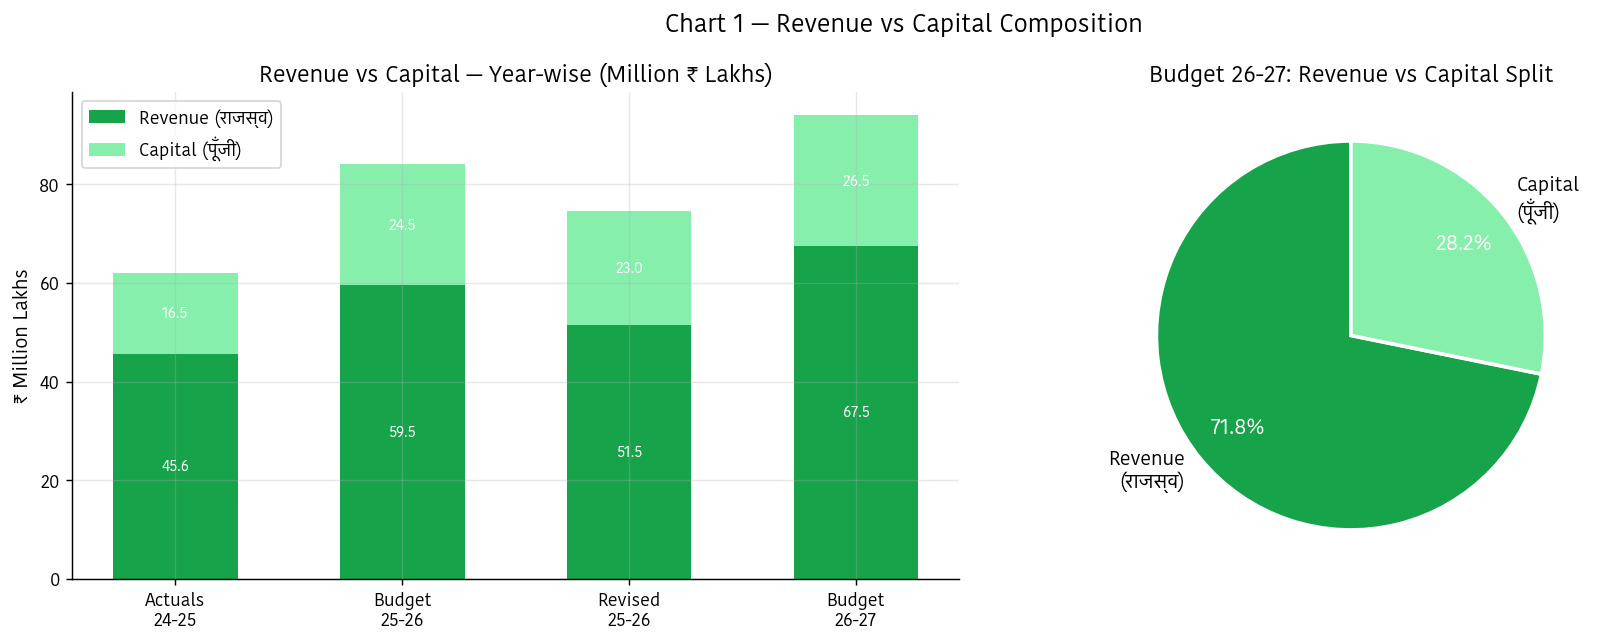

In [7]:
plt.rcParams['font.family'] = 'Kohinoor Devanagari'
rev_vals = [df[df['Type']=='राजस्व'][c].sum() / 1e6 for c in NUM_COLS]
cap_vals = [df[df['Type']=='पूँजी'][c].sum() / 1e6 for c in NUM_COLS]
y_lbls   = ['Actuals\n24-25', 'Budget\n25-26', 'Revised\n25-26', 'Budget\n26-27']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Stacked bar ──────────────────────────────────────────────────────────────
ax = axes[0]
x  = np.arange(4)
b1 = ax.bar(x, rev_vals, color='#16A34A', label='Revenue (राजस्व)', width=0.55)
b2 = ax.bar(x, cap_vals, bottom=rev_vals, color='#86EFAC', label='Capital (पूँजी)', width=0.55)
ax.set_xticks(x); ax.set_xticklabels(y_lbls)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}'))
ax.set_title('Revenue vs Capital — Year-wise (Million ₹ Lakhs)')
ax.set_ylabel('₹ Million Lakhs'); ax.legend()
for bar in [*b1, *b2]:
    h = bar.get_height()
    if h > 0.5:
        y = bar.get_y() + h/2
        ax.text(bar.get_x()+bar.get_width()/2, y, f'{h:.1f}',
                ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')

# ── Pie: Budget 26-27 ───────────────────────────────────────────────────────
ax2 = axes[1]
pie_v   = [max(rev_vals[-1], 0.001), max(cap_vals[-1], 0.001)]   # guard against zero
pie_lbl = ['Revenue\n(राजस्व)', 'Capital\n(पूँजी)']
wedges, texts, autotexts = ax2.pie(
    pie_v, labels=pie_lbl, autopct='%1.1f%%',
    colors=['#16A34A', '#86EFAC'], startangle=90,
    wedgeprops=dict(linewidth=2, edgecolor='white'),
    textprops={'fontsize': 11}, pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('Budget 26-27: Revenue vs Capital Split')

fig.suptitle('Chart 1 — Revenue vs Capital Composition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** **Revenue expenditure heavily dominates the budget (~70%).** This indicates a "service-heavy" state profile where the majority of funds are directed toward operational costs, salaries, pensions, and social transfers, rather than asset creation (Capital).

### 4.2 — Year-on-Year Grand Total Trend

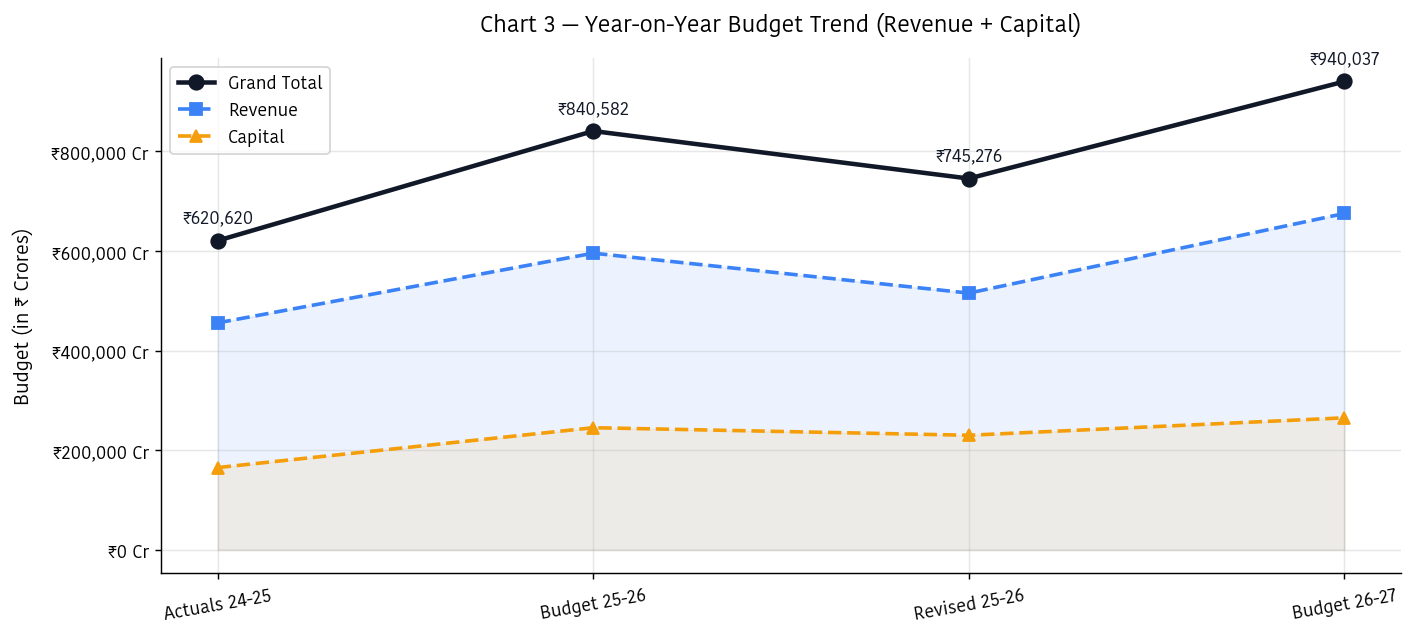

In [8]:
# 1. Prepare Data (Divide by 100 to convert Lakhs directly to Crores)
grand = [df[c].sum() / 100 for c in NUM_COLS]
rev_line = [df[df['Type'] == 'राजस्व'][c].sum() / 100 for c in NUM_COLS]
cap_line = [df[df['Type'] == 'पूँजी'][c].sum() / 100 for c in NUM_COLS]

# 2. Setup Figure and Axes
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(YEAR_LBLS))

# 3. Plot Lines
ax.plot(x, grand, 'o-', color='#111827', lw=2.5, ms=8, label='Grand Total')
ax.plot(x, rev_line, 's--', color='#3B82F6', lw=2.0, ms=7, label='Revenue')
ax.plot(x, cap_line, '^--', color='#F59E0B', lw=2.0, ms=7, label='Capital')

# 4. Fill Area Underneath for Styling
ax.fill_between(x, rev_line, alpha=0.09, color='#3B82F6')
ax.fill_between(x, cap_line, alpha=0.09, color='#F59E0B')

# 5. Annotate Grand Total Data Points
for i, g in enumerate(grand):
    ax.annotate(f'₹{g:,.0f}', (i, g), xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=10, fontweight='bold', color='#111827')

# 6. Axis Labels and Formatting
ax.set_xticks(x)
ax.set_xticklabels(YEAR_LBLS, rotation=10)

# Format Y-axis to cleanly display "₹[Value] Cr"
formatter = mticker.FuncFormatter(lambda v, pos: f'₹{v:,.0f} Cr')
ax.yaxis.set_major_formatter(formatter)

# Set Titles and Labels
ax.set_ylabel('Budget (in ₹ Crores)', fontsize=11, labelpad=10)
ax.set_title('Chart 3 — Year-on-Year Budget Trend (Revenue + Capital)', pad=15, fontweight='bold')
ax.legend(loc='upper left', frameon=True)

# 7. Render
plt.tight_layout()
plt.show()

> **Insight:** **Aggressive, uninterrupted growth.** The state budget has expanded from ₹62,061 Cr (Actuals 24-25) to ₹94,003 Cr (Budget 26-27). This represents a massive **~51% jump** over just two fiscal cycles, showcasing significant economic expansion and increased state spending capacity.

### 4.3 — % Change Distribution (Budget 26-27 vs Budget 25-26)

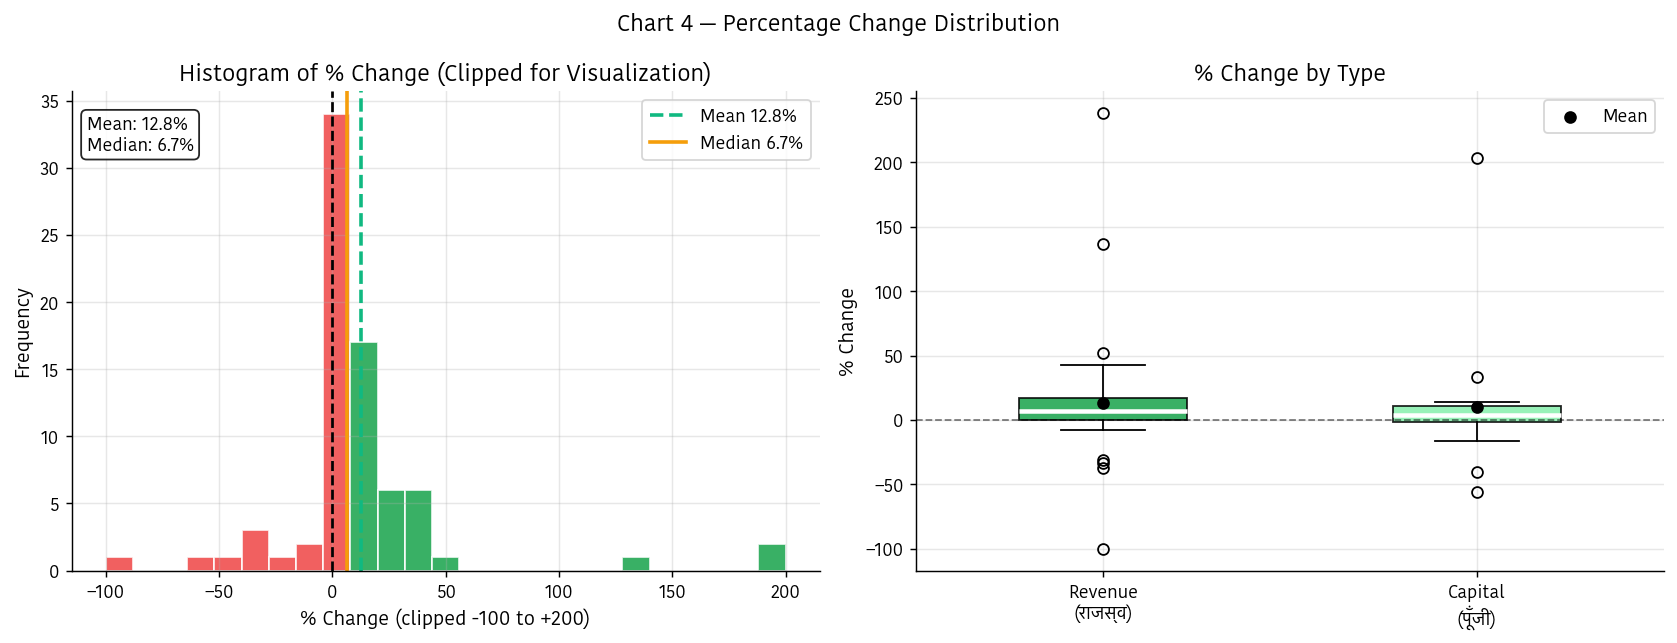

Overall Mean % Change   : 12.78%
Overall Median % Change : 6.68%
Revenue Mean % Change   : 13.52%
Capital Mean % Change   : 10.39%


In [9]:
# Prepare data
pc = df['Percent_Change'].dropna()
pc_clip = pc.clip(-100, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# ── Histogram ────────────────────────────────────────────────────────────────
ax = axes[0]

n, bins, patches = ax.hist(pc_clip,bins=25,color='#16A34A',edgecolor='white',alpha=0.85)

# Highlight negatives
for p in patches:
    if p.get_x() < 0:
        p.set_facecolor('#EF4444')

# Mean & Median
mean_val = pc.mean()
median_val = pc.median()

ax.axvline(0, color='black', lw=1.5, ls='--')
ax.axvline(mean_val, color='#10B981', lw=2, ls='--', label=f'Mean {mean_val:.1f}%')
ax.axvline(median_val, color='#F59E0B', lw=2, label=f'Median {median_val:.1f}%')

# Labels
ax.set_xlabel('% Change (clipped -100 to +200)')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of % Change (Clipped for Visualization)')
ax.legend()

# Insight box
ax.text(0.02, 0.95,f'Mean: {mean_val:.1f}%\nMedian: {median_val:.1f}%',
    transform=ax.transAxes,fontsize=10,verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
# ── Boxplot ──────────────────────────────────────────────────────────────────
ax2 = axes[1]

data_rev = df[df['Type']=='राजस्व']['Percent_Change'].dropna()
data_cap = df[df['Type']=='पूँजी']['Percent_Change'].dropna()

bp = ax2.boxplot([data_rev, data_cap],patch_artist=True,
    widths=0.45,medianprops=dict(color='white', lw=2.5))
# Colors
for patch, clr in zip(bp['boxes'], ['#16A34A', '#86EFAC']):
    patch.set_facecolor(clr)
    patch.set_alpha(0.85)

# Mean markers
ax2.scatter([1, 2],[data_rev.mean(), data_cap.mean()],color='black',
    zorder=3,label='Mean')

# Labels
ax2.set_xticklabels(['Revenue\n(राजस्व)', 'Capital\n(पूँजी)'])
ax2.set_ylabel('% Change')
ax2.set_title('% Change by Type')

ax2.axhline(0, color='black', lw=1, ls='--', alpha=0.5)
ax2.legend()

# ── Title ────────────────────────────────────────────────────────────────────
fig.suptitle('Chart 4 — Percentage Change Distribution',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()
# ── Key Insights (print) ──────────────────────────────────────────────────────
print(f"Overall Mean % Change   : {mean_val:.2f}%")
print(f"Overall Median % Change : {median_val:.2f}%")
print(f"Revenue Mean % Change   : {data_rev.mean():.2f}%")
print(f"Capital Mean % Change   : {data_cap.mean():.2f}%")

> **Insight:** **Targeted spikes rather than uniform growth.** While the median growth rate across all departments is steady, the distribution is heavily skewed by a few extreme outliers receiving massive budget hikes, while several legacy accounts face minor cuts.